In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

df = pd.read_csv('batch_normalization_dataset_2000.csv')

df.head()

,X,Y,class
0,1.102601,5.127108,1.0
1,-0.776755,2.591605,0.0
2,-0.584276,2.495956,1.0
3,-0.718286,0.565262,0.0
4,1.983105,4.545387,1.0


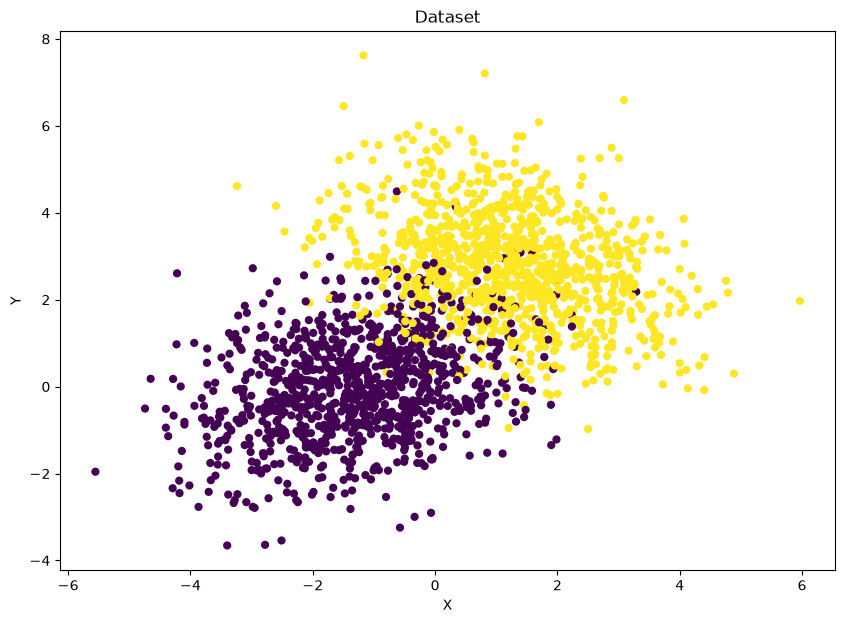

In [3]:
plt.figure(figsize=(10, 7))

plt.scatter(
    df['X'],
    df['Y'],
    c=df['class'],
    s=24
)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Dataset')
plt.show()

In [4]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [6]:
print("X = ",X)
print("y = ",y)

X =  [[ 1.10260141  5.12710801]
 [-0.77675528  2.59160529]
 [-0.58427599  2.49595572]
 ...
 [-1.64690639 -0.68337368]
 [ 1.90560142  3.9904712 ]
 [ 2.90820593  1.51303922]]
y =  [1. 0. 1. ... 0. 1. 1.]


In [7]:
import tensorflow 
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense
from tensorflow.keras.layers import BatchNormalization

Model without Batch normalization

In [9]:
model = Sequential()
model.add(Dense(2,activation='relu',input_dim=2))
model.add(Dense(2,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [10]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [12]:
history1 = model.fit(X,y,epochs=200,validation_split=0.2)

Epoch 1/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4806 - loss: 0.7563 - val_accuracy: 0.5000 - val_loss: 0.7806
Epoch 2/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4919 - loss: 0.7342 - val_accuracy: 0.5075 - val_loss: 0.7596
Epoch 3/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5038 - loss: 0.7202 - val_accuracy: 0.5125 - val_loss: 0.7449
Epoch 4/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5144 - loss: 0.7104 - val_accuracy: 0.5175 - val_loss: 0.7338
Epoch 5/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5250 - loss: 0.7032 - val_accuracy: 0.5350 - val_loss: 0.7259
Epoch 6/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5319 - loss: 0.6975 - val_accuracy: 0.5450 - val_loss: 0.7206
Epoch 7/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5425 - loss: 0.6925 - val_accuracy: 0.5500 - val_loss: 0.7142
Epoch 8/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5581 - loss: 0.6877 - val_accuracy: 0.5700 - v

model with batch Normalization

In [14]:
model=Sequential()
model.add(Dense(3,activation='relu',input_dim=2))
model.add(BatchNormalization())
model.add(Dense(2,activation='relu'))
model.add(BatchNormalization())
model.add(Dense(1,activation='sigmoid'))


In [15]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3)              │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2)              │             8 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 30 (120.00 B)

 Non-trainable params: 10 (40.00 B)

In [16]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [17]:
history2= model.fit(X,y,epochs=200,validation_split=0.02)

Epoch 1/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4617 - loss: 0.7543 - val_accuracy: 0.4500 - val_loss: 0.6752
Epoch 2/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6679 - loss: 0.6941 - val_accuracy: 0.8000 - val_loss: 0.6235
Epoch 3/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7372 - loss: 0.6434 - val_accuracy: 0.8000 - val_loss: 0.5874
Epoch 4/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7740 - loss: 0.5957 - val_accuracy: 0.8000 - val_loss: 0.5569
Epoch 5/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7944 - loss: 0.5535 - val_accuracy: 0.8250 - val_loss: 0.5323
Epoch 6/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8097 - loss: 0.5179 - val_accuracy: 0.8500 - val_loss: 0.5101
Epoch 7/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8255 - loss: 0.4764 - val_accuracy: 0.8500 - val_loss: 0.4855
Epoch 8/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8429 - loss: 0.4449 - val_accuracy: 0.9000 - v

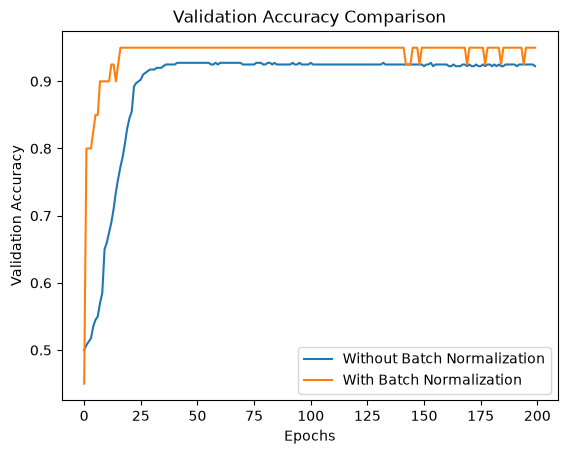

In [ ]:
plt.plot(history1.history['val_accuracy'], label='Without Batch Normalization')
plt.plot(history2.history['val_accuracy'], label='With Batch Normalization')

plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Comparison')
plt.legend()
plt.show()